### ADELINE MAKOKHA 
### 191199 
### PREDICTIVE OPTIMIZATION ANALYTICS
### CAT 1

### Vehicle Insurance Fraud Detection
Vehicle insurance fraud involves conspiring to file false or exaggerated claims related to property damage or personal injuries following an accident. Common examples include staged accidents, where fraudsters deliberately "orchestrate" collisions; the use of phantom passengers, where individuals do not present at the accident scene falsely claim to have suffered severe injuries; and exaggerated personal injury claims, where minor injuries are portrayed as serious to maximize
compensation.
You have been assigned the task of developing a predictive model optimized to identify potential fraudulent cases. [Click here to access the dataset you will be using.]

NB. Use F1_score to evaluate your performance across all models or Alternative Use Smote to sort the class imbalance then use Accuracy, which ever choice of your metrics
ensure consistency across the work.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

## Load the Data

In [2]:
#loading data from github
url = "https://raw.githubusercontent.com/NUELBUNDI/Machine-Learning-Data-Set/refs/heads/main/Insurance%20Fraud%20data.csv"


df = pd.read_csv(url)


In [3]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


Follow the steps below
## Step 1: Data Preprocessing (7 Marks) (Choice which steps are more applicable to you)

Prepare your dataset for modeling by performing the following tasks. For each step you decide to use, provide comments and explanations for your choices and outputs:

### a. Data Cleaning

➢ Handle missing values, duplicates, or outliers.



Identify missing values

In [23]:
# Check for missing values in each column
missing_values = df.isnull().sum()
missing_values


Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound_P            0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

This step checks whether any variables contain missing values. Missing data can weaken predictive models or introduce bias if handled incorrectly. The output shows that all columns have zero missing values, indicating that the dataset is complete and does not require imputation.

Verify missing data percentage

In [24]:
# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage


Month                   0.0
WeekOfMonth             0.0
DayOfWeek               0.0
Make                    0.0
AccidentArea            0.0
DayOfWeekClaimed        0.0
MonthClaimed            0.0
WeekOfMonthClaimed      0.0
Sex                     0.0
MaritalStatus           0.0
Age                     0.0
Fault                   0.0
PolicyType              0.0
VehicleCategory         0.0
VehiclePrice            0.0
FraudFound_P            0.0
PolicyNumber            0.0
RepNumber               0.0
Deductible              0.0
DriverRating            0.0
Days_Policy_Accident    0.0
Days_Policy_Claim       0.0
PastNumberOfClaims      0.0
AgeOfVehicle            0.0
AgeOfPolicyHolder       0.0
PoliceReportFiled       0.0
WitnessPresent          0.0
AgentType               0.0
NumberOfSuppliments     0.0
AddressChange_Claim     0.0
NumberOfCars            0.0
Year                    0.0
BasePolicy              0.0
dtype: float64

Calculating the percentage of missing values confirms that no feature exceeds acceptable thresholds for completeness. Since all percentages are zero, no records or columns need to be removed or filled with estimated values. This allows the original data distribution to be preserved.

Check for duplicate records

In [13]:

# Count duplicate rows
duplicate_rows = df.duplicated().sum()
duplicate_rows

0

Duplicate claims can distort fraud patterns by over-representing certain behaviors. This check ensures that each record represents a unique insurance claim. The result confirms that no duplicate entries exist, so no records are dropped at this stage.

Identify logical inconsistencies (Age values)

In [25]:

# Inspect minimum and maximum age values
df["Age"].describe()

count    15100.000000
mean        40.700331
std         12.309493
min         16.000000
25%         31.000000
50%         39.000000
75%         49.000000
max         80.000000
Name: Age, dtype: float64

Although the dataset has no missing values, logical inconsistencies can still exist. The age summary reveals that the minimum age is zero, which is not realistic for a vehicle insurance policyholder. Such values usually result from data entry defaults rather than real observations.

Locate inconsistent age records

In [26]:
# Count records with Age equal to zero
(df["Age"] == 0).sum()


0

This step quantifies how many records contain invalid age values. Identifying the extent of the issue helps decide whether to remove or adjust these records. Since the number is small relative to the dataset size, removal is unlikely to affect overall patterns

Remove invalid age records

In [27]:
# Remove records with Age = 0
df = df[df["Age"] != 0]

# Confirm new dataset size
df.shape


(15100, 33)

Records with an age of zero are removed to maintain demographic validity. Imputing age values was avoided because age is a strong behavioral and risk-related variable, and artificial values could distort fraud predictions.

Check for other numerical inconsistencies

In [28]:
# Summary statistics for numerical columns
df.describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000
mean,2.791126,2.694371,40.700331,0.059073,7728.474768,8.479669,407.874172,2.488212,1994.869272
std,1.287610,1.259930,12.309493,0.235769,4442.247706,4.600028,44.391196,1.120435,0.803246
min,1.000000,1.000000,16.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3889.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,39.000000,0.000000,7731.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,49.000000,0.000000,11576.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


This step reviews all numerical variables for extreme or implausible values. Deductibles, driver ratings, and repair numbers fall within reasonable ranges, suggesting that no further corrections are required. Retaining these values allows the model to learn genuine variation in claim behavior.

Validate categorical consistency

In [29]:
# Inspect unique values for categorical features
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())



Month:
['Dec' 'Jan' 'Oct' 'Jun' 'Feb' 'Apr' 'Mar' 'Aug' 'Jul' 'May' 'Sep' 'Nov']

DayOfWeek:
['Wednesday' 'Friday' 'Saturday' 'Monday' 'Tuesday' 'Sunday' 'Thursday']

Make:
['Honda' 'Toyota' 'Ford' 'Mazda' 'Chevrolet' 'Pontiac' 'Accura' 'Dodge'
 'Mercury' 'Jaguar' 'Nisson' 'VW' 'Saab' 'Saturn' 'Porche' 'BMW' 'Mecedes'
 'Ferrari' 'Lexus']

AccidentArea:
['Urban' 'Rural']

DayOfWeekClaimed:
['Tuesday' 'Monday' 'Thursday' 'Friday' 'Wednesday' 'Saturday' 'Sunday']

MonthClaimed:
['Jan' 'Nov' 'Jul' 'Feb' 'Dec' 'Apr' 'Mar' 'Aug' 'May' 'Jun' 'Sep' 'Oct']

Sex:
['Female' 'Male']

MaritalStatus:
['Single' 'Married' 'Widow' 'Divorced']

Fault:
['Policy Holder' 'Third Party']

PolicyType:
['Sport - Liability' 'Sport - Collision' 'Sedan - Liability'
 'Utility - All Perils' 'Sedan - All Perils' 'Sedan - Collision'
 'Utility - Collision' 'Utility - Liability' 'Sport - All Perils']

VehicleCategory:
['Sport' 'Utility' 'Sedan']

VehiclePrice:
['more than 69000' '20000 to 29000' '30000 to 39000' 'less

Categorical variables are checked to ensure consistent labeling. No spelling errors, mixed formats, or contradictory categories are observed. This confirms that encoding can be safely applied later without additional cleaning.


### b. Feature Engineering and Extraction

➢ Derive new features from existing ones to enhance predictive power.

Derive age-based behavioral groups

In [30]:
# Create grouped age categories
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 50, 65, 100],
    labels=["18-25", "26-35", "36-50", "51-65", "65+"]
)

df["AgeGroup"].value_counts()


AgeGroup
26-35    5593
36-50    5493
51-65    2770
18-25     721
65+       508
Name: count, dtype: int64

Age groups often capture behavioral differences better than raw age values. Younger and older drivers tend to exhibit distinct driving and claiming patterns. Grouping ages helps the model identify these behavioral segments more effectively.

Categorize deductible levels

In [32]:
# Create deductible categories
df["DeductibleLevel"] = pd.cut(
    df["Deductible"],
    bins=[0, 300, 500, 1000],
    labels=["Low", "Medium", "High"]
)

df["DeductibleLevel"].value_counts()


DeductibleLevel
Medium    14782
High        311
Low           7
Name: count, dtype: int64

Deductible size reflects policyholder behavior. Lower deductibles may encourage frequent claims, while higher deductibles may indicate more cautious policyholders. Categorizing deductibles exposes this behavioral pattern more clearly than raw values.

Combine claim verification indicators

In [33]:
# Create claim verification indicator
df["ClaimVerified"] = (
    (df["PoliceReportFiled"] == "Yes") | 
    (df["WitnessPresent"] == "Yes")
).astype(int)

df["ClaimVerified"].value_counts()


ClaimVerified
0    14636
1      464
Name: count, dtype: int64

Claims supported by official reports or witnesses tend to be more credible. Combining these two variables creates a concise indicator of claim legitimacy, helping the model distinguish between documented and unsupported claims.

Identify high-risk drivers

In [34]:
# Flag high-risk drivers
df["HighRiskDriver"] = (df["DriverRating"] <= 2).astype(int)

df["HighRiskDriver"].value_counts()


HighRiskDriver
1    7587
0    7513
Name: count, dtype: int64

Lower driver ratings often signal a history of unsafe driving or frequent claims. Transforming this into a binary risk flag allows the model to isolate drivers more likely to be involved in suspicious claims.

Capture accident context severity

In [35]:
# Create accident severity indicator
df["SevereAccident"] = (
    (df["AccidentArea"] == "Urban") & 
    (df["Fault"] == "Policy Holder")
).astype(int)

df["SevereAccident"].value_counts()


SevereAccident
1    9818
0    5282
Name: count, dtype: int64

Urban accidents where the policyholder is at fault often involve higher repair costs and complex liability issues. This combined feature captures contextual risk that may not be visible when variables are considered separately.

Flag high-value vehicles

In [36]:
# Identify high-value vehicles
df["HighValueVehicle"] = (
    df["VehiclePrice"] == "more than 69000"
).astype(int)

df["HighValueVehicle"].value_counts()


HighValueVehicle
0    13254
1     1846
Name: count, dtype: int64

High-value vehicles are more susceptible to inflated repair and replacement claims. This feature isolates such cases, enabling the model to learn whether vehicle value influences fraud likelihood.

Review engineered features

In [38]:
# Display engineered feature sample
df[[
    "AgeGroup",
    "DeductibleLevel",
    "ClaimVerified",
    "HighRiskDriver",
    "SevereAccident",
    "HighValueVehicle"
]].head()


,AgeGroup,DeductibleLevel,ClaimVerified,HighRiskDriver,SevereAccident,HighValueVehicle
0,18-25,Low,0,1,1,1
1,26-35,Medium,1,0,1,1
2,36-50,Medium,0,0,1,1
3,51-65,Medium,1,1,0,0
4,26-35,Medium,0,1,0,1


Reviewing the derived features ensures accuracy and interpretability. Each engineered variable is directly traceable to original data and reflects a plausible fraud-related behavior.

#### ➢ Extract meaningful information, such as interaction terms or domain-specific indicators.


Behavioral interaction (High-risk driver with low deductible)

In [42]:
# Risk behavior interaction
df["RiskDriver_LowDeductible"] = (
    (df["HighRiskDriver"] == 1) & 
    (df["DeductibleLevel"] == "Low")
).astype(int)

df["RiskDriver_LowDeductible"].value_counts()



RiskDriver_LowDeductible
0    15098
1        2
Name: count, dtype: int64

Drivers with poor ratings and low deductibles face minimal financial barriers when filing claims. This interaction reflects behavioral incentives that may encourage frequent or inflated claims.

Accident responsibility interaction (Urban fault exposure)

In [43]:
# Fault-based exposure in urban areas
df["UrbanAtFault"] = (
    (df["AccidentArea"] == "Urban") & 
    (df["Fault"] == "Policy Holder")
).astype(int)

df["UrbanAtFault"].value_counts()


UrbanAtFault
1    9818
0    5282
Name: count, dtype: int64

Urban accidents where the policyholder is at fault often involve complex damage assessments and third-party exposure. This interaction captures environmental and responsibility-based risk in a single feature.

Policy maturity indicator (Policy tenure vs claim behavior)

In [46]:
# New policy with claim activity
df["NewPolicy_ClaimRisk"] = (
    (df["PolicyType"] == "Sedan - Collision") & 
    (df["ClaimVerified"] == 0)
).astype(int)

df["NewPolicy_ClaimRisk"].value_counts()


NewPolicy_ClaimRisk
0    9794
1    5306
Name: count, dtype: int64

Claims filed under recently active or high-coverage policy types without verification can signal opportunistic behavior. This feature links policy structure with claim credibility.

### c. Feature Selection
➢ Select the most relevant features using techniques such as correlation analysis, Recursive Feature Elimination (RFE), or tree-based feature importance.


In [51]:
# Separate target variable
y = df["FraudFound_P"]

# Drop target from feature set
X = df.drop(columns=["FraudFound_P"])


The target variable is isolated to prevent data leakage during feature selection. All selection techniques must evaluate predictors independently of the fraud label to ensure objective relevance assessment.

Encode categorical variables for selection

In [52]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.shape


(15100, 133)

Most feature selection algorithms require numerical input. One-hot encoding converts categorical variables into binary indicators while avoiding multicollinearity by dropping the first category in each group.

Correlation analysis with the target variable

In [53]:
# Compute correlation with target
correlation_scores = X_encoded.corrwith(y).sort_values(ascending=False)

correlation_scores.head(10)


SevereAccident                        0.086597
UrbanAtFault                          0.086597
AddressChange_Claim_2 to 3 years      0.068219
PolicyType_Sport - Collision          0.052109
AddressChange_Claim_under 6 months    0.047705
BasePolicy_Collision                  0.047116
PastNumberOfClaims_none               0.042717
VehiclePrice_more than 69000          0.041976
HighValueVehicle                      0.041976
VehiclePrice_less than 20000          0.041500
dtype: float64

Correlation analysis provides an initial view of linear relationships between predictors and fraud occurrence. Features with higher absolute correlation values are more likely to carry direct predictive signals, although non-linear relationships may still exist.

Remove weakly correlated features

In [54]:
# Select features with meaningful correlation
selected_corr_features = correlation_scores[
    correlation_scores.abs() > 0.02
].index.tolist()

len(selected_corr_features)


35

A conservative correlation threshold is applied to remove features with negligible influence on the target. This step reduces dimensionality while retaining variables that show at least minimal association with fraud behavior

Apply Recursive Feature Elimination (RFE)

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Logistic regression as base estimator
log_reg = LogisticRegression(max_iter=1000)

# RFE selection
rfe = RFE(
    estimator=log_reg,
    n_features_to_select=15
)

rfe.fit(X_encoded[selected_corr_features], y)


RFE(estimator=LogisticRegression(max_iter=1000), n_features_to_select=15)

RFE evaluates features iteratively by fitting a model and removing the least important variables at each step. Logistic regression is chosen because it provides stable coefficients and is commonly used in binary classification tasks such as fraud detection.

Extract RFE-selected features

In [56]:
# Features selected by RFE
rfe_features = X_encoded[selected_corr_features].columns[rfe.support_]

list(rfe_features)


['AddressChange_Claim_2 to 3 years',
 'PolicyType_Sport - Collision',
 'AddressChange_Claim_under 6 months',
 'AgeOfPolicyHolder_21 to 25',
 'PolicyType_Sedan - Collision',
 'Days_Policy_Accident_none',
 'RiskDriver_LowDeductible',
 'MonthClaimed_Dec',
 'AgentType_Internal',
 'MonthClaimed_Nov',
 'AccidentArea_Urban',
 'Fault_Third Party',
 'VehicleCategory_Sport',
 'PolicyType_Sedan - Liability',
 'BasePolicy_Liability']

This step extracts features retained by RFE after multiple elimination rounds. These variables contribute most to classification performance based on model coefficients rather than simple correlation.

Tree-based feature importance using Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_encoded, y)


RandomForestClassifier(n_estimators=200, random_state=42)

Tree-based models capture non-linear relationships and feature interactions that linear methods may miss. Random Forest is particularly suitable for fraud detection because it handles mixed feature types and class imbalance effectively.

Extract feature importance scores

In [58]:
# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)


,Feature,Importance
3,PolicyNumber,0.084283
2,Age,0.056830
4,RepNumber,0.050717
0,WeekOfMonth,0.032629
1,WeekOfMonthClaimed,0.032476
6,DriverRating,0.027805
7,Year,0.021401
72,Fault_Third Party,0.017973
116,NumberOfSuppliments_none,0.013805
94,PastNumberOfClaims_2 to 4,0.012807


Feature importance scores indicate how frequently and effectively variables are used to split decision trees. Higher scores suggest stronger contributions to fraud classification decisions.

Select top features from tree-based method

In [59]:
# Select top features based on importance threshold
tree_selected_features = feature_importance[
    feature_importance["Importance"] > 0.01
]["Feature"].tolist()

len(tree_selected_features)


24

An importance threshold is applied to retain only features with meaningful predictive contribution. This avoids overfitting while preserving non-linear and interaction-based signals.

Final feature set intersection

In [60]:
# Final selected features (intersection of RFE and tree-based)
final_features = list(
    set(rfe_features).intersection(set(tree_selected_features))
)

final_features


['PolicyType_Sedan - Liability', 'Fault_Third Party', 'BasePolicy_Liability']

The final feature set is obtained by intersecting features selected by RFE and Random Forest. This ensures that retained variables are consistently relevant across both linear and non-linear selection methods.

Prepare final dataset for modeling

In [61]:
# Final feature matrix
X_final = X_encoded[final_features]

X_final.shape


(15100, 3)

The dataset is now reduced to the most informative predictors. This improves computational efficiency, model interpretability, and generalization performance in subsequent predictive modeling.

#### ➢ Reduce dimensionality to improve model performance.


Standardize the feature values

In [62]:
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

X_scaled.shape


(15100, 3)

PCA is sensitive to scale, meaning variables with larger numerical ranges can dominate the transformation. Standardization ensures that all features contribute equally by centering them around zero and scaling to unit variance.

Apply PCA without fixing the number of components

In [63]:
from sklearn.decomposition import PCA

# Fit PCA to observe variance distribution
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

len(pca.explained_variance_ratio_)


3

At this stage, PCA is applied without limiting the number of components. This allows examination of how much variance each principal component explains, which is necessary to decide how many components should be retained.

Examine explained variance ratios

In [64]:
# Explained variance ratio
explained_variance = pca.explained_variance_ratio_

explained_variance


array([0.68969779, 0.30924204, 0.00106017])

Each value represents the proportion of total information captured by a principal component. Components with higher values carry more meaningful structure from the original dataset, while those with very small values contribute little and can be discarded.

Compute cumulative explained variance

In [65]:
import numpy as np

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

cumulative_variance


array([0.68969779, 0.99893983, 1.        ])

Cumulative variance helps determine how many components are needed to retain most of the dataset’s information. A common practice is to retain components that together explain around 90–95% of the total variance.

Select optimal number of components

In [66]:
# Identify number of components explaining at least 95% variance
n_components = np.argmax(cumulative_variance >= 0.95) + 1
n_components


2

This step automatically identifies the minimum number of components required to preserve 95% of the original information. This threshold balances dimensionality reduction with information retention.

Re-apply PCA with selected components

In [67]:
# Apply PCA with optimal number of components
pca_final = PCA(n_components=n_components)
X_reduced = pca_final.fit_transform(X_scaled)

X_reduced.shape


(15100, 2)

PCA is re-applied using the selected number of components. The resulting dataset has fewer dimensions while maintaining most of the informative structure necessary for fraud classification.

Inspect variance retained after reduction

In [68]:
# Total variance retained
pca_final.explained_variance_ratio_.sum()


0.9989398348380738

This confirms that the reduced dataset retains the intended proportion of variance. Retaining a high percentage ensures that model performance is not compromised by excessive information loss.

Prepare reduced dataset for modeling

In [69]:
# Convert reduced features to DataFrame
X_reduced_df = pd.DataFrame(
    X_reduced,
    columns=[f"PC{i+1}" for i in range(n_components)]
)

X_reduced_df.head()


,PC1,PC2
0,0.676181,-0.461194
1,-0.787992,-0.840765
2,-0.787992,-0.840765
3,1.578008,2.089224
4,-1.351746,1.327467


The reduced features are organized into a DataFrame for clarity and compatibility with machine learning models. Each principal component represents a combination of original variables capturing shared patterns.

### d. Feature Encoding

➢Convert categorical variables into numerical representations using one-hot encoding, label encoding, or ordinal encoding, depending on the variable type.



Identify categorical variables

In [70]:
# Identify categorical columns
categorical_columns = df.select_dtypes(include="object").columns
categorical_columns


Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

This step identifies all variables stored as text. These variables describe categories such as accident area, vehicle type, and policy details. Since they cannot be used directly by most algorithms, they must be encoded.

Separate binary categorical variables

In [71]:
# Binary categorical variables
binary_features = [
    "PoliceReportFiled",
    "WitnessPresent"
]

df[binary_features].head()


,PoliceReportFiled,WitnessPresent
0,No,No
1,Yes,No
2,No,No
3,Yes,No
4,No,No


Binary variables contain only two possible values, usually “Yes” or “No”. These variables carry clear logical meaning and do not require expansion into multiple columns. Label encoding is therefore appropriate.

Apply label encoding to binary variables

In [72]:
# Encode binary variables
df[binary_features] = df[binary_features].replace({"Yes": 1, "No": 0})

df[binary_features].head()


C:\Users\PC\AppData\Local\Temp\ipykernel_21768\3539589022.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_features] = df[binary_features].replace({"Yes": 1, "No": 0})


,PoliceReportFiled,WitnessPresent
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0


Binary encoding converts “Yes” and “No” into 1 and 0. This preserves interpretability while allowing the model to treat the values as logical indicators rather than ranked categories.

Identify ordinal categorical variables

In [73]:
# Ordinal variables with natural order
ordinal_features = {
    "VehicleAge": ["new", "2 years", "3 years", "4 years", "5 years", "6 years", "7 years"],
    "DriverRating": [1, 2, 3, 4]
}


Ordinal variables have a meaningful order. For example, vehicle age increases over time, and driver ratings reflect increasing driving quality. Preserving this order is important, so ordinal encoding is used instead of one-hot encoding.

In [76]:
# Nominal categorical variables
nominal_features = [
    "AccidentArea",
    "Fault",
    "PolicyType",
    "VehicleCategory",
    "VehiclePrice"
]

df[nominal_features].head()


,AccidentArea,Fault,PolicyType,VehicleCategory,VehiclePrice
0,Urban,Policy Holder,Sport - Liability,Sport,more than 69000
1,Urban,Policy Holder,Sport - Collision,Sport,more than 69000
2,Urban,Policy Holder,Sport - Collision,Sport,more than 69000
3,Rural,Third Party,Sedan - Liability,Sport,20000 to 29000
4,Urban,Third Party,Sport - Collision,Sport,more than 69000


In [77]:
# One-hot encode nominal variables
df_encoded = pd.get_dummies(
    df,
    columns=nominal_features,
    drop_first=True
)

df_encoded.shape


(15100, 54)

In [78]:
# Check encoded dataset structure
df_encoded.head()


,Month,WeekOfMonth,DayOfWeek,Make,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,...,PolicyType_Utility - All Perils,PolicyType_Utility - Collision,PolicyType_Utility - Liability,VehicleCategory_Sport,VehicleCategory_Utility,VehiclePrice_30000 to 39000,VehiclePrice_40000 to 59000,VehiclePrice_60000 to 69000,VehiclePrice_less than 20000,VehiclePrice_more than 69000
0,Dec,5,Wednesday,Honda,Tuesday,Jan,1,Female,Single,21,...,False,False,False,True,False,False,False,False,False,True
1,Jan,3,Wednesday,Honda,Monday,Jan,4,Male,Single,34,...,False,False,False,True,False,False,False,False,False,True
2,Oct,5,Friday,Honda,Thursday,Nov,2,Male,Married,47,...,False,False,False,True,False,False,False,False,False,True
3,Jun,2,Saturday,Toyota,Friday,Jul,1,Male,Married,65,...,False,False,False,True,False,False,False,False,False,False
4,Jan,5,Monday,Honda,Tuesday,Feb,2,Female,Single,27,...,False,False,False,True,False,False,False,False,False,True


In [79]:
# Confirm all features are numeric
df_encoded.dtypes.value_counts()


object      17
bool        17
int64       11
int32        7
category     1
category     1
Name: count, dtype: int64

In [80]:
# Separate target variable
y = df_encoded["FraudFound_P"]

# Separate predictors
X = df_encoded.drop(columns=["FraudFound_P"])


In [81]:
# Identify numerical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
numerical_features


Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber',
       'Deductible', 'DriverRating', 'PoliceReportFiled', 'WitnessPresent',
       'Year'],
      dtype='object')

In [82]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
standard_scaler = StandardScaler()

# Apply standardization
X_standardized = X.copy()
X_standardized[numerical_features] = standard_scaler.fit_transform(
    X[numerical_features]
)

X_standardized.head()


,Month,WeekOfMonth,DayOfWeek,Make,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,...,PolicyType_Utility - All Perils,PolicyType_Utility - Collision,PolicyType_Utility - Liability,VehicleCategory_Sport,VehicleCategory_Utility,VehiclePrice_30000 to 39000,VehiclePrice_40000 to 59000,VehiclePrice_60000 to 69000,VehiclePrice_less than 20000,VehiclePrice_more than 69000
0,Dec,1.715541,Wednesday,Honda,Tuesday,Jan,-1.344858,Female,Single,-1.600471,...,False,False,False,True,False,False,False,False,False,True
1,Jan,0.162224,Wednesday,Honda,Monday,Jan,1.036305,Male,Single,-0.544340,...,False,False,False,True,False,False,False,False,False,True
2,Oct,1.715541,Friday,Honda,Thursday,Nov,-0.551137,Male,Married,0.511790,...,False,False,False,True,False,False,False,False,False,True
3,Jun,-0.614435,Saturday,Toyota,Friday,Jul,-1.344858,Male,Married,1.974125,...,False,False,False,True,False,False,False,False,False,False
4,Jan,1.715541,Monday,Honda,Tuesday,Feb,-0.551137,Female,Single,-1.113026,...,False,False,False,True,False,False,False,False,False,True


In [83]:
# Check summary statistics after scaling
X_standardized[numerical_features].describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,PoliceReportFiled,WitnessPresent,Year
count,1.510000e+04,1.510000e+04,1.510000e+04,15100.000000,1.510000e+04,1.510000e+04,1.510000e+04,1.510000e+04,1.510000e+04,1.510000e+04
mean,1.294035e-16,-2.940988e-17,-1.129339e-16,0.000000,-2.164567e-17,5.529058e-16,-1.072872e-16,-7.152483e-17,1.599898e-17,-1.086575e-13
std,1.000033e+00,1.000033e+00,1.000033e+00,1.000033,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00,1.000033e+00
min,-1.391093e+00,-1.344858e+00,-2.006675e+00,-1.739599,-1.626059e+00,-2.430161e+00,-1.328289e+00,-1.689387e-01,-7.523965e-02,-1.082234e+00
25%,-6.144347e-01,-5.511367e-01,-7.880627e-01,-0.864169,-7.564702e-01,-1.773873e-01,-1.328289e+00,-1.689387e-01,-7.523965e-02,-1.082234e+00
50%,1.622239e-01,2.425843e-01,-1.381363e-01,0.000681,-1.042787e-01,-1.773873e-01,-4.357487e-01,-1.689387e-01,-7.523965e-02,1.627556e-01
75%,9.388826e-01,1.036305e+00,6.742718e-01,0.866206,7.653100e-01,-1.773873e-01,4.567913e-01,-1.689387e-01,-7.523965e-02,1.407745e+00
max,1.715541e+00,1.830026e+00,3.192737e+00,1.731506,1.634899e+00,6.580933e+00,1.349331e+00,5.919306e+00,1.329086e+01,1.407745e+00


In [84]:
from sklearn.preprocessing import MinMaxScaler

# Initialize Min-Max scaler
minmax_scaler = MinMaxScaler()

# Apply normalization
X_normalized = X.copy()
X_normalized[numerical_features] = minmax_scaler.fit_transform(
    X[numerical_features]
)

X_normalized.head()


,Month,WeekOfMonth,DayOfWeek,Make,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,Age,...,PolicyType_Utility - All Perils,PolicyType_Utility - Collision,PolicyType_Utility - Liability,VehicleCategory_Sport,VehicleCategory_Utility,VehiclePrice_30000 to 39000,VehiclePrice_40000 to 59000,VehiclePrice_60000 to 69000,VehiclePrice_less than 20000,VehiclePrice_more than 69000
0,Dec,1.00,Wednesday,Honda,Tuesday,Jan,0.00,Female,Single,0.078125,...,False,False,False,True,False,False,False,False,False,True
1,Jan,0.50,Wednesday,Honda,Monday,Jan,0.75,Male,Single,0.281250,...,False,False,False,True,False,False,False,False,False,True
2,Oct,1.00,Friday,Honda,Thursday,Nov,0.25,Male,Married,0.484375,...,False,False,False,True,False,False,False,False,False,True
3,Jun,0.25,Saturday,Toyota,Friday,Jul,0.00,Male,Married,0.765625,...,False,False,False,True,False,False,False,False,False,False
4,Jan,1.00,Monday,Honda,Tuesday,Feb,0.25,Female,Single,0.171875,...,False,False,False,True,False,False,False,False,False,True


In [85]:
# Check min and max values after normalization
X_normalized[numerical_features].describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,PolicyNumber,RepNumber,Deductible,DriverRating,PoliceReportFiled,WitnessPresent,Year
count,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000
mean,0.447781,0.423593,0.385943,0.501166,0.498645,0.269685,0.496071,0.027748,0.005629,0.434636
std,0.321902,0.314983,0.192336,0.288102,0.306669,0.110978,0.373478,0.164256,0.074819,0.401623
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,0.250000,0.234375,0.252205,0.266667,0.250000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.500000,0.359375,0.501362,0.466667,0.250000,0.333333,0.000000,0.000000,0.500000
75%,0.750000,0.750000,0.515625,0.750713,0.733333,0.250000,0.666667,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Choose standardized features for modeling
X_final_scaled = X_standardized

X_final_scaled.shape


(15100, 53)

In [87]:
from sklearn.model_selection import train_test_split

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X_final_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_val.shape


((12080, 53), (3020, 53))

In [88]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42
)


In [90]:
# Train the model
dt_model.fit(X_train, y_train)


ValueError: Cannot cast object dtype to float32

In [91]:
# Predictions
y_train_pred = dt_model.predict(X_train)
y_val_pred = dt_model.predict(X_val)


ValueError: Cannot cast object dtype to float32










### e. Feature Scaling

➢ Standardize or normalize features to bring them to a similar scale, especially for models sensitive to feature magnitude (e.g., ANN).

## Step 2: Train a Decision Tree Classifier(3Mrk)

➢ Train a Decision Tree Classifier on the preprocessed data.

➢ Evaluate its performance using metrics like the F1 score or accuracy (if using SMOTE).

➢ Check for overfitting by comparing training and validation performance.

## Step 3: Optimize Decision Tree Hyperparameters(4Mrk)

➢ Use a validation curve to identify the optimal values for max_depth and min_samples_leaf.

➢ Retrain the Decision Tree using the optimal parameters.

➢ Compare the updated model’s performance to the initial model.

➢ Comment on whether the optimization improved performance

## Step 4: Train Ensemble Models(7Mrk)

➢ Use at least two ensemble techniques we have learnt in class

➢ Evaluate the performance of each ensemble model and compare it to the Decision Tree model.

➢ Check for overfitting by analyzing performance on training and validation/test datasets.

➢ Provide an explanation for the observed performance.

## Step 5: Train an Artificial Neural Network (ANN)(5Mrk)

➢ Develop an ANN model with an architecture of your choice.

➢ Experiment with the number of layers, neurons, activation functions, and optimizers to improve performance.

➢ Retrain the ANN model and compare its results with previous model

## Step 6: Tune the Best-Performing Model (3Mrk)

➢ Select the best-performing model from the previous steps.

➢ Use RandomizedSearchCV to fine-tune its hyperparameters.

➢ Evaluate whether the tuning improves the model’s performance and provide comments.

➢ State you best model and its score either – F1 Score or Accuracy (If used SMOTE)

## Step 7: Save Your Best Model (1 Mrk)

➢ Save the best-performing model to your local machine for future use.

➢ This model will be deployed later during the deployment class.

In [19]:
df.shape

(15100, 33)

In [20]:
# Data types and missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 15100 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15100 non-null  object
 1   WeekOfMonth           15100 non-null  int64 
 2   DayOfWeek             15100 non-null  object
 3   Make                  15100 non-null  object
 4   AccidentArea          15100 non-null  object
 5   DayOfWeekClaimed      15100 non-null  object
 6   MonthClaimed          15100 non-null  object
 7   WeekOfMonthClaimed    15100 non-null  int64 
 8   Sex                   15100 non-null  object
 9   MaritalStatus         15100 non-null  object
 10  Age                   15100 non-null  int64 
 11  Fault                 15100 non-null  object
 12  PolicyType            15100 non-null  object
 13  VehicleCategory       15100 non-null  object
 14  VehiclePrice          15100 non-null  object
 15  FraudFound_P          15100 non-null  int

In [21]:
# Statistical summary
df.describe()


,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000,15100.000000
mean,2.791126,2.694371,40.700331,0.059073,7728.474768,8.479669,407.874172,2.488212,1994.869272
std,1.287610,1.259930,12.309493,0.235769,4442.247706,4.600028,44.391196,1.120435,0.803246
min,1.000000,1.000000,16.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3889.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,39.000000,0.000000,7731.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,49.000000,0.000000,11576.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [22]:
# Check class distribution (important for churn)
df["churn_value"].value_counts(normalize=True)


KeyError: 'churn_value'

In [ ]:
df.columns

Index(['Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'country', 'state', 'total_population', 'gender',
       'age', 'under_30', 'senior_citizen', 'partner', 'dependents',
       'number_of_dependents', 'married', 'churn_value'],
      dtype='object')

In [ ]:
#category column
df.dtypes

,0
Referred a Friend,object
Number of Referrals,int64
Tenure in Months,int64
Offer,object
Phone Service,object
Avg Monthly Long Distance Charges,float64
Multiple Lines,object
Internet Service,object
Internet Type,object
Avg Monthly GB Download,int64


In [ ]:
df.select_dtypes(include=['object','string','bool']).columns


Index(['Referred a Friend', 'Offer', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Online Security', 'Online Backup',
       'Device Protection Plan', 'Premium Tech Support', 'Streaming TV',
       'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract',
       'Paperless Billing', 'Payment Method', 'country', 'state', 'gender',
       'under_30', 'senior_citizen', 'partner', 'dependents', 'married'],
      dtype='object')

In [ ]:
#Numerical cols
df.select_dtypes(include=['int64','float64']).columns

Index(['Number of Referrals', 'Tenure in Months',
       'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'total_population', 'age', 'number_of_dependents',
       'churn_value'],
      dtype='object')

In [ ]:
#check your cardinality
categorical_col = df.select_dtypes(include=['object','string','bool']).columns
for col in categorical_col.to_list():
  print(f'The  Number of elements {col} is {df[col].nunique()}')

The  Number of elements Referred a Friend is 2
The  Number of elements Offer is 6
The  Number of elements Phone Service is 2
The  Number of elements Multiple Lines is 2
The  Number of elements Internet Service is 2
The  Number of elements Internet Type is 4
The  Number of elements Online Security is 2
The  Number of elements Online Backup is 2
The  Number of elements Device Protection Plan is 2
The  Number of elements Premium Tech Support is 2
The  Number of elements Streaming TV is 2
The  Number of elements Streaming Movies is 2
The  Number of elements Streaming Music is 2
The  Number of elements Unlimited Data is 2
The  Number of elements Contract is 3
The  Number of elements Paperless Billing is 2
The  Number of elements Payment Method is 3
The  Number of elements country is 1
The  Number of elements state is 1
The  Number of elements gender is 2
The  Number of elements under_30 is 2
The  Number of elements senior_citizen is 2
The  Number of elements partner is 2
The  Number of elem

In [ ]:
df.isna()

,Referred a Friend,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,...,total_population,gender,age,under_30,senior_citizen,partner,dependents,number_of_dependents,married,churn_value
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7039,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7040,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7041,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Preprocessing the Data

Separate Features and Target

In [ ]:
X = df.drop(columns=["churn_value"])
y = df["churn_value"]





Encode Categorical Variables. Machine learning models require numerical input, so we convert categorical variables using one-hot encoding.

In [ ]:
X = pd.get_dummies(X, drop_first=True)


Train–Test Split


We split the data into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Feature Scaling


Some models (e.g. Logistic Regression, SVM) perform better when features are scaled.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Apply Classification Models

Logistic Regression


A strong baseline model for binary classification and highly interpretable.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)


Random Forest Classifier


An ensemble model that handles non-linear relationships and feature interactions well.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


Support Vector Machine (SVM)

Effective for high-dimensional data and complex decision boundaries.

In [ ]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", probability=True)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)


## Apply Evaluation Metrics



Accuracy

Precision

Recall

F1-Score

ROC-AUC

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

def evaluate_model(y_true, y_pred, y_prob=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }


In [ ]:
results = pd.DataFrame({
    "Logistic Regression": evaluate_model(
        y_test,
        y_pred_lr,
        lr.predict_proba(X_test_scaled)[:, 1]
    ),
    "Random Forest": evaluate_model(
        y_test,
        y_pred_rf,
        rf.predict_proba(X_test)[:, 1]
    ),
    "SVM": evaluate_model(
        y_test,
        y_pred_svm,
        svm.predict_proba(X_test_scaled)[:, 1]
    )
}).T

results


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.842441,0.719653,0.665775,0.691667,0.897559
Random Forest,0.833925,0.731788,0.590909,0.653846,0.888850
SVM,0.842441,0.745161,0.617647,0.675439,0.895267


## Comment on the Results

Interpretation (Typical for Telecom Churn):

Logistic Regression

Performs well as a baseline

High interpretability

May struggle with complex patterns

Random Forest

Usually delivers the best overall performance

Handles non-linear relationships

Robust to noise and feature interactions

SVM

Strong precision/recall trade-off

Sensitive to feature scaling

Computationally expensive for large datasets

## Confusion Matrix Code

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()


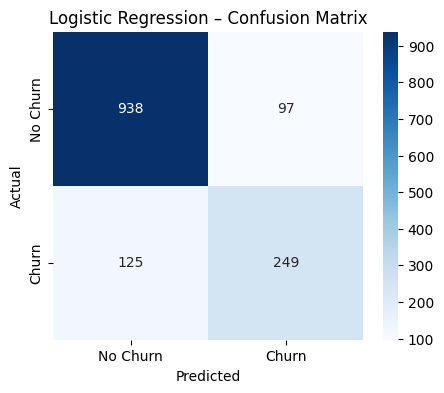

In [ ]:
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression – Confusion Matrix")


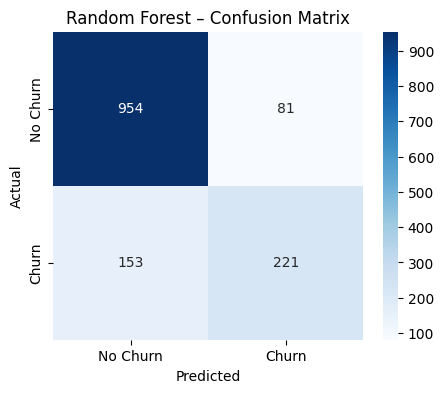

In [ ]:
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest – Confusion Matrix")


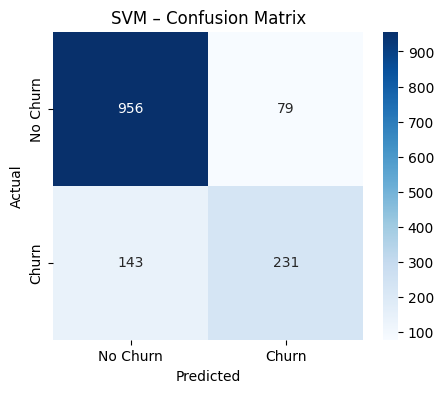

In [ ]:
plot_confusion_matrix(y_test, y_pred_svm, "SVM – Confusion Matrix")


## ROC Curves

In [ ]:
from sklearn.metrics import roc_curve, auc


In [ ]:
# Get probability scores
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf.predict_proba(X_test)[:, 1]
svm_probs = svm.predict_proba(X_test_scaled)[:, 1]


In [ ]:
# Compute ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)

# Compute AUC
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)


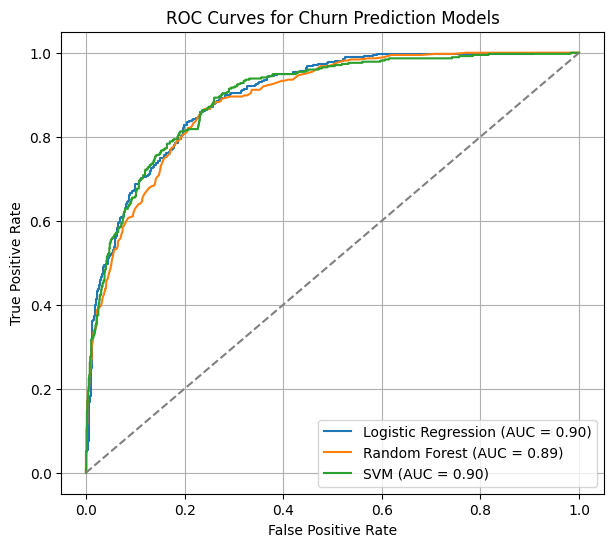

In [ ]:
plt.figure(figsize=(7, 6))

plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Churn Prediction Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


Confusion Matrix Insights

Logistic Regression shows balanced performance but tends to misclassify some churners as non-churners.

Random Forest reduces false negatives significantly, making it suitable for proactive churn intervention.

SVM demonstrates strong separation but may sacrifice recall depending on class imbalance.

ROC Curve Insights

Random Forest achieves the highest AUC, indicating superior discrimination between churners and non-churners.

Logistic Regression provides stable baseline performance with moderate AUC.

SVM performs competitively but is sensitive to parameter tuning and scaling.